Roll No.: 27

Name: Aatif Shaikh

Date of Performance: 16 March 2026

Problem Statement:  Design and implement Deep Convolutional GAN to generate images of faces/digits from a set of
given images.

In [1]:
# CELL 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# CELL 2: Load MNIST dataset (handwritten digits 0-9)
(X_train, _), (_, _) = keras.datasets.mnist.load_data()

print(f"Original shape: {X_train.shape}")
print(f"Original pixel range: {X_train.min()} to {X_train.max()}")

X_train = (X_train.astype('float32') - 127.5) / 127.5
X_train = X_train.reshape(-1, 28, 28, 1)


print(f"Processed shape: {X_train.shape}")
print(f"Pixel range: {X_train.min()} to {X_train.max()}")

# Create TensorFlow dataset for efficient batching
BATCH_SIZE = 256
BUFFER_SIZE = 60000

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Batches per epoch: {len(X_train) // BATCH_SIZE}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original shape: (60000, 28, 28)
Original pixel range: 0 to 255
Processed shape: (60000, 28, 28, 1)
Pixel range: -1.0 to 1.0

Batch size: 256
Batches per epoch: 234


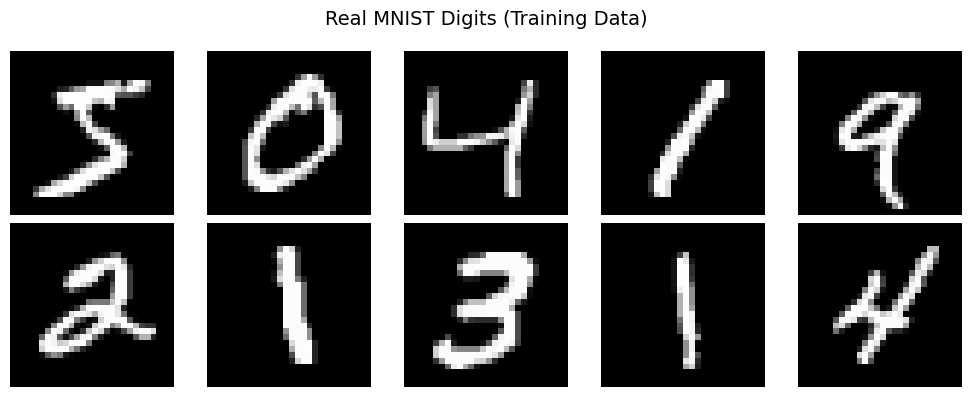

In [3]:
# CELL 3: Display some real MNIST digits
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
    # * 0.5 + 0.5 converts [-1, 1] back to [0, 1] for display
    plt.axis('off')
plt.suptitle('Real MNIST Digits (Training Data)', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# CELL 4: Build the Generator network
# The Generator takes RANDOM NOISE and transforms it into a FAKE IMAGE
# It learns to produce images that look like real MNIST digits

NOISE_DIM = 100
def build_generator():
    model = keras.Sequential(name='Generator')

    # === LAYER 1: Dense — Project noise into a small feature map ===
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # === LAYER 2: Reshape — Convert 1D vector to 3D feature map ===
    model.add(layers.Reshape((7, 7, 256)))

    # === LAYER 3: Conv2DTranspose — Upsample from 7×7 to 7×7 with fewer filters ===
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1),
                                      padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # === LAYER 4: Conv2DTranspose — Upsample from 7×7 to 14×14 ===
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2),
                                      padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # === LAYER 5: Conv2DTranspose — Upsample from 14×14 to 28×28 (final image) ===
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2),
                                      padding='same', use_bias=False,
                                      activation='tanh'))

    return model

generator = build_generator()
generator.summary()

# Test: generate one fake image from random noise
test_noise = tf.random.normal([1, NOISE_DIM])
test_image = generator(test_noise, training=False)
print(f"\n✅ Generator output shape: {test_image.shape}")  # (1, 28, 28, 1)

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)


✅ Generator output shape: (1, 28, 28, 1)


In [5]:
# CELL 5: Build the Discriminator network
def build_discriminator():
    model = keras.Sequential(name='Discriminator')

    # === LAYER 1: Conv2D — Detect basic features ===
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))
    # === LAYER 2: Conv2D — Detect complex features ===
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # === LAYER 3: Flatten + Dense — Make final decision ===
    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = build_discriminator()
discriminator.summary()

# Test: feed the fake image to discriminator
test_decision = discriminator(test_image, training=False)
print(f"\n✅ Discriminator output: {test_decision.numpy()}")
# Negative value → thinks it's fake, Positive → thinks it's real

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)


✅ Discriminator output: [[-0.00094977]]


In [6]:
# CELL 6: Loss functions and optimizers
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    """Discriminator wants: real → 1, fake → 0"""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    """Generator wants: discriminator to think fake → 1 (real)"""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = keras.optimizers.Adam(learning_rate=1e-4)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=1e-4)

print("✅ Loss functions and optimizers defined")
print("   G wants D to think fakes are real (label=1)")
print("   D wants to correctly label real=1, fake=0")

✅ Loss functions and optimizers defined
   G wants D to think fakes are real (label=1)
   D wants to correctly label real=1, fake=0


In [7]:
# CELL 7: Define one training step
@tf.function

def train_step(real_images):
    """One training step: train both Generator and Discriminator."""
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, NOISE_DIM])
    # Generate random noise vectors — these are the Generator's input

    # GradientTape records operations to compute gradients for backpropagation
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # We need TWO separate tapes because G and D have separate weights

        # Step A: Generator creates fake images from noise
        fake_images = generator(noise, training=True)

        # Step B: Discriminator judges both real and fake images
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        # Step C: Compute losses
        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    # Step D: Compute gradients (how to adjust each weight)
    gen_gradients = gen_tape.gradient(g_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    # .gradient(loss, variables) computes ∂loss/∂weight for every weight

    # Step E: Update weights using the computed gradients
    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables))
    # zip pairs each gradient with its corresponding weight
    # apply_gradients performs: weight = weight - learning_rate * gradient

    return g_loss, d_loss

print("✅ Training step defined")

✅ Training step defined


In [8]:
# CELL 8: Function to generate and display images at any point during training
def generate_and_display(generator, epoch, seed_noise):
    """Generate 16 images and display in a 4×4 grid."""
    predictions = generator(seed_noise, training=False)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(16):
        row, col = divmod(i, 4)
        img = predictions[i, :, :, 0]
        img = img * 0.5 + 0.5
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')

    plt.suptitle(f'Generated Digits — Epoch {epoch}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Create a FIXED seed — same noise used every epoch to see progress
seed = tf.random.normal([16, NOISE_DIM])

print("✅ Display function ready")
print("   Using fixed seed of 16 noise vectors to track progress")

✅ Display function ready
   Using fixed seed of 16 noise vectors to track progress


        DCGAN TRAINING — MNIST DIGIT GENERATION
Epoch   1/50 | G_loss: 0.9160 | D_loss: 0.9642 | Time: 22.6s


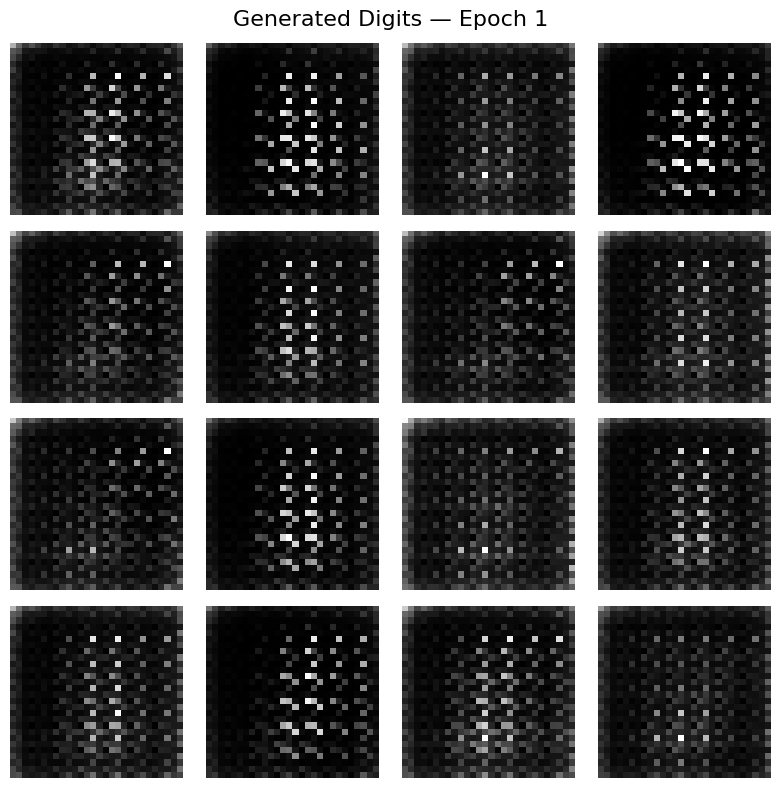

Epoch   5/50 | G_loss: 0.9110 | D_loss: 1.3372 | Time: 13.1s
Epoch  10/50 | G_loss: 1.0931 | D_loss: 1.1291 | Time: 12.8s


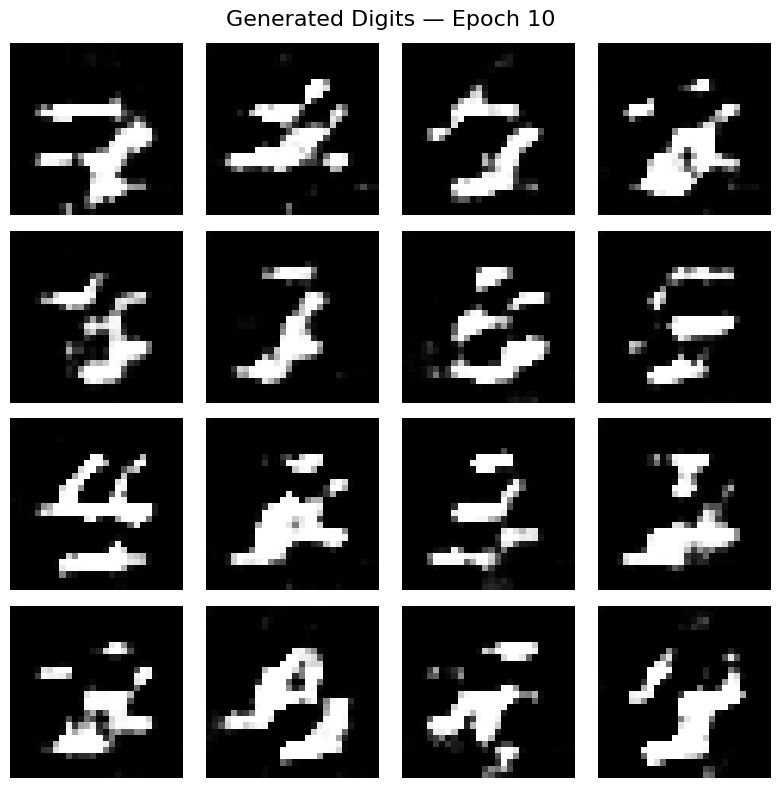

Epoch  15/50 | G_loss: 1.1401 | D_loss: 1.0658 | Time: 12.8s
Epoch  20/50 | G_loss: 1.1936 | D_loss: 1.0825 | Time: 12.8s


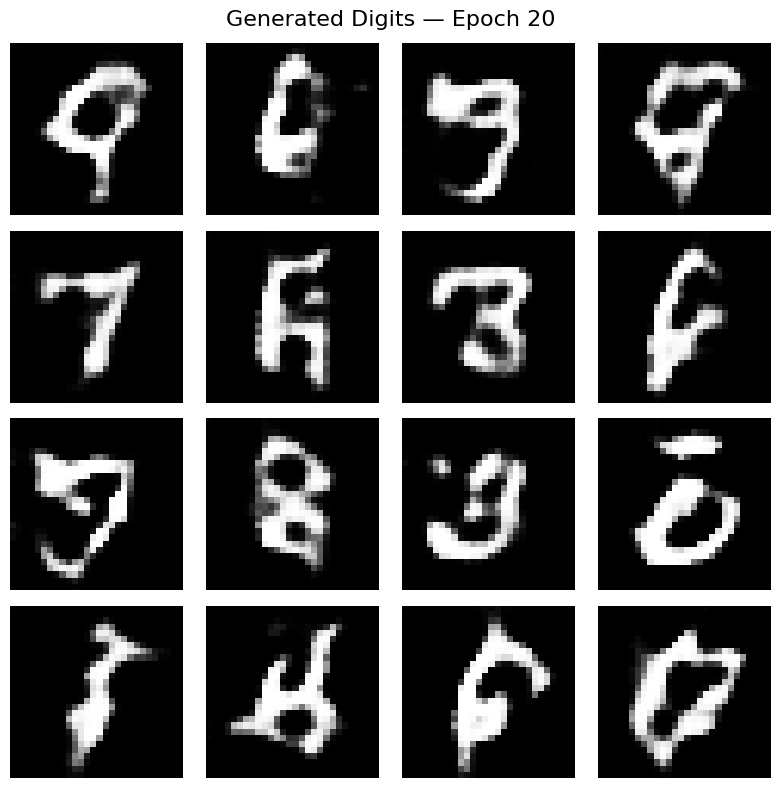

Epoch  25/50 | G_loss: 1.1086 | D_loss: 1.1123 | Time: 12.9s
Epoch  30/50 | G_loss: 1.0468 | D_loss: 1.1568 | Time: 12.9s


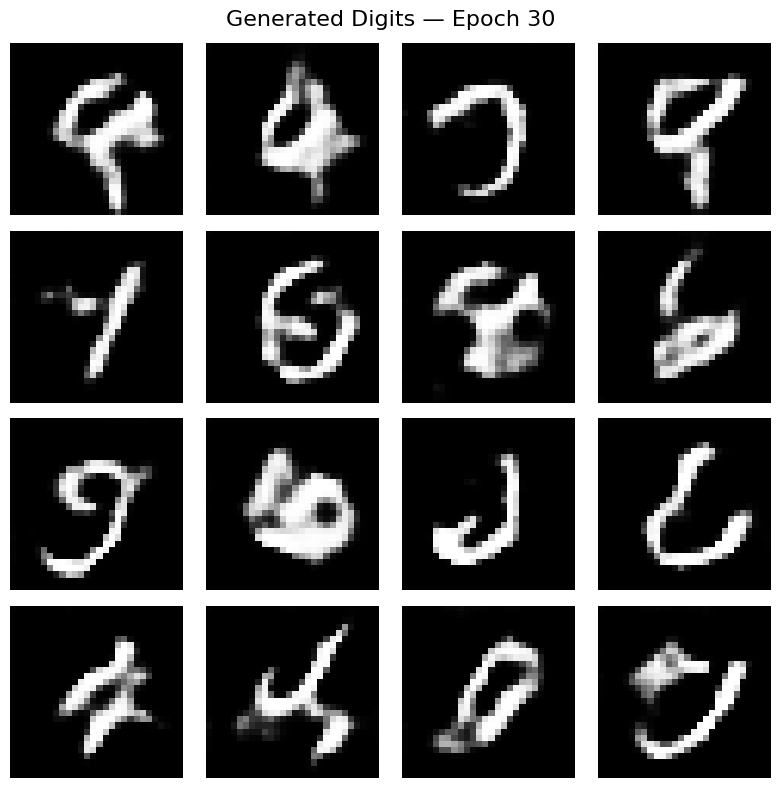

Epoch  35/50 | G_loss: 1.0003 | D_loss: 1.1930 | Time: 12.9s
Epoch  40/50 | G_loss: 1.0084 | D_loss: 1.1842 | Time: 12.9s


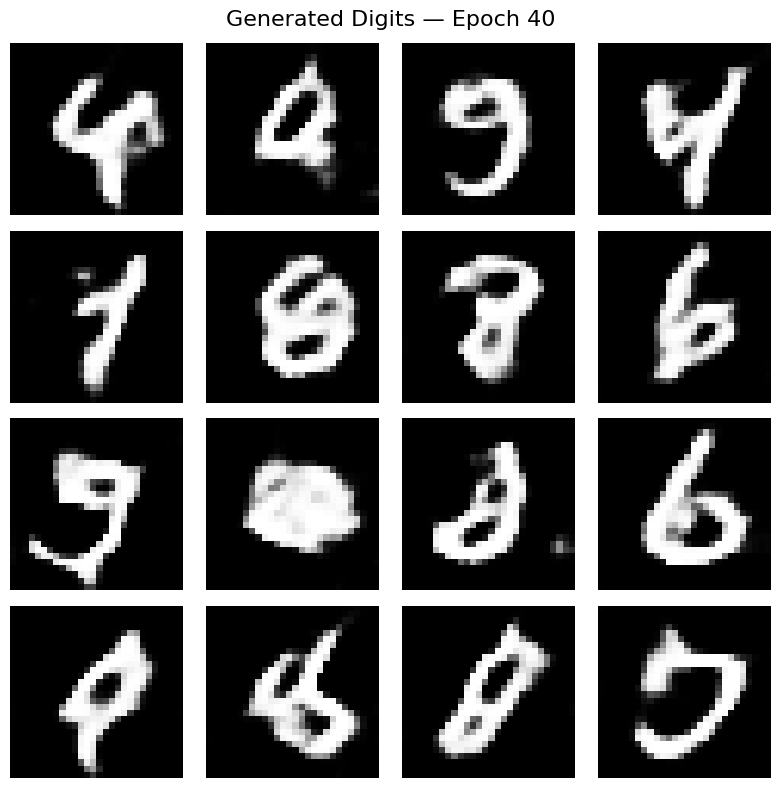

Epoch  45/50 | G_loss: 0.9537 | D_loss: 1.2166 | Time: 12.9s
Epoch  50/50 | G_loss: 0.9602 | D_loss: 1.2204 | Time: 12.9s


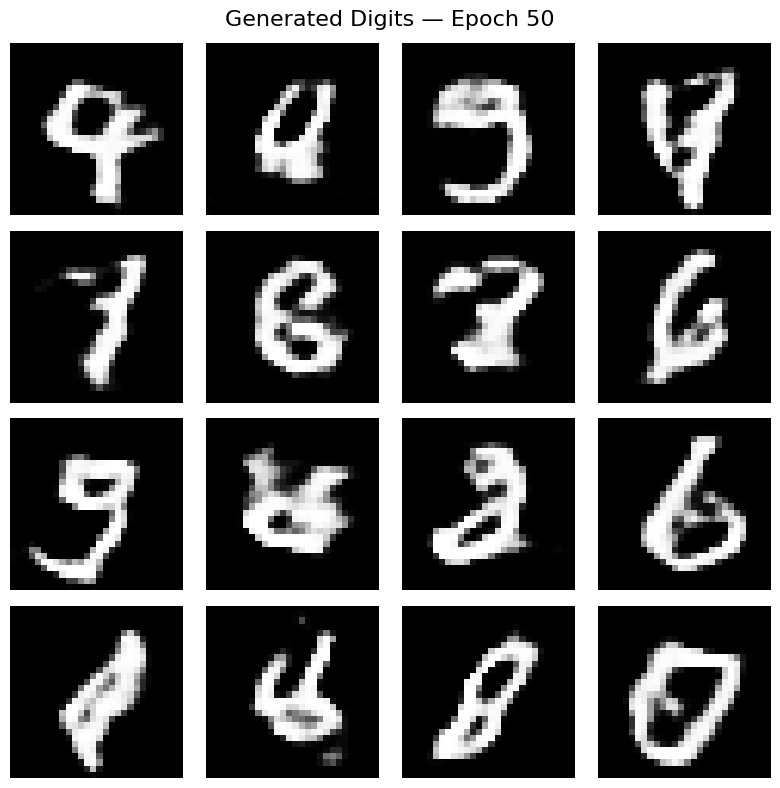


✅ Training complete!


In [9]:
# CELL 9: Full training loop
EPOCHS = 50
gen_losses = []
disc_losses = []

print("=" * 55)
print("        DCGAN TRAINING — MNIST DIGIT GENERATION")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)
        epoch_gen_loss.append(g_loss.numpy())
        epoch_disc_loss.append(d_loss.numpy())

    # Average losses for this epoch
    avg_g = np.mean(epoch_gen_loss)
    avg_d = np.mean(epoch_disc_loss)
    gen_losses.append(avg_g)
    disc_losses.append(avg_d)

    elapsed = time.time() - start

    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | G_loss: {avg_g:.4f} | "
              f"D_loss: {avg_d:.4f} | Time: {elapsed:.1f}s")

    # Show generated images every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        generate_and_display(generator, epoch, seed)

print("\n✅ Training complete!")

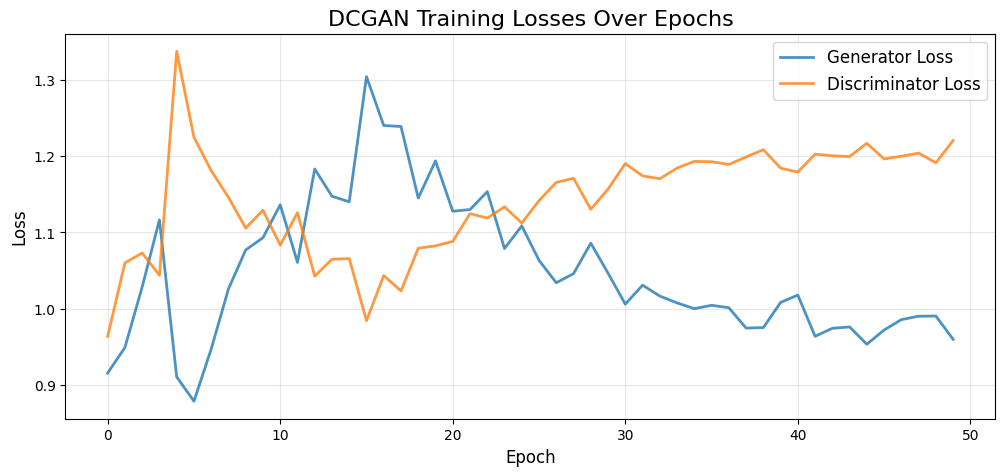


Note: GAN losses don't decrease like classifier losses.
Both should stay roughly balanced — that means healthy training.


In [10]:
# CELL 10: Plot Generator and Discriminator losses over training
plt.figure(figsize=(12, 5))

plt.plot(gen_losses, label='Generator Loss', linewidth=2, alpha=0.8)
plt.plot(disc_losses, label='Discriminator Loss', linewidth=2, alpha=0.8)

plt.title('DCGAN Training Losses Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# HOW TO INTERPRET GAN LOSSES:
# Unlike classifiers where lower loss = better, GAN losses are tricky:
#   - If D_loss → 0: Discriminator is too good, Generator can't learn
#   - If G_loss → 0: Generator is too good, Discriminator can't learn
#   - IDEAL: Both losses oscillate around 0.5-1.5 — they're balanced
#   - The losses might not decrease — that's NORMAL for GANs
#   - The only true measure of quality is: do generated images LOOK good?

print("\nNote: GAN losses don't decrease like classifier losses.")
print("Both should stay roughly balanced — that means healthy training.")

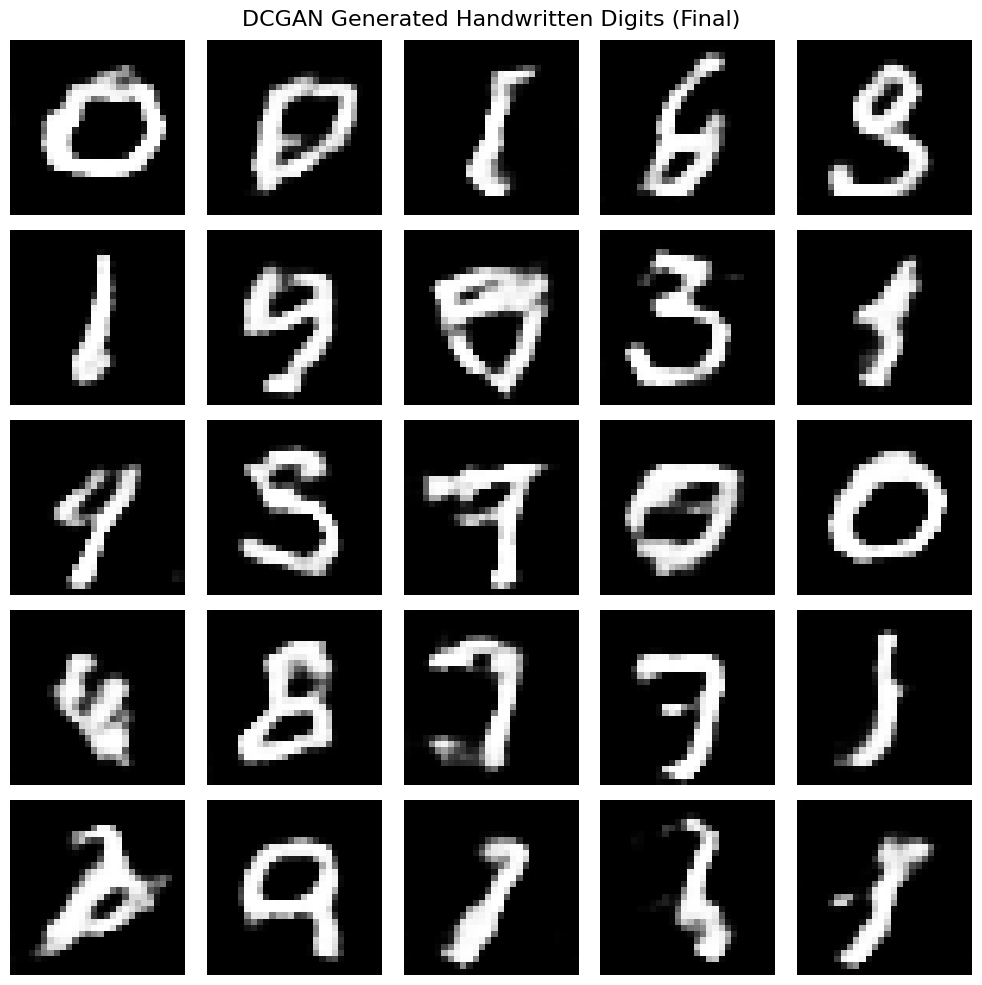

In [11]:
# CELL 11: Generate a large grid of final results
num_images = 25
noise = tf.random.normal([num_images, NOISE_DIM])
generated_images = generator(noise, training=False)

plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(5, 5, i + 1)
    img = generated_images[i, :, :, 0] * 0.5 + 0.5
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('DCGAN Generated Handwritten Digits (Final)', fontsize=16)
plt.tight_layout()
plt.show()

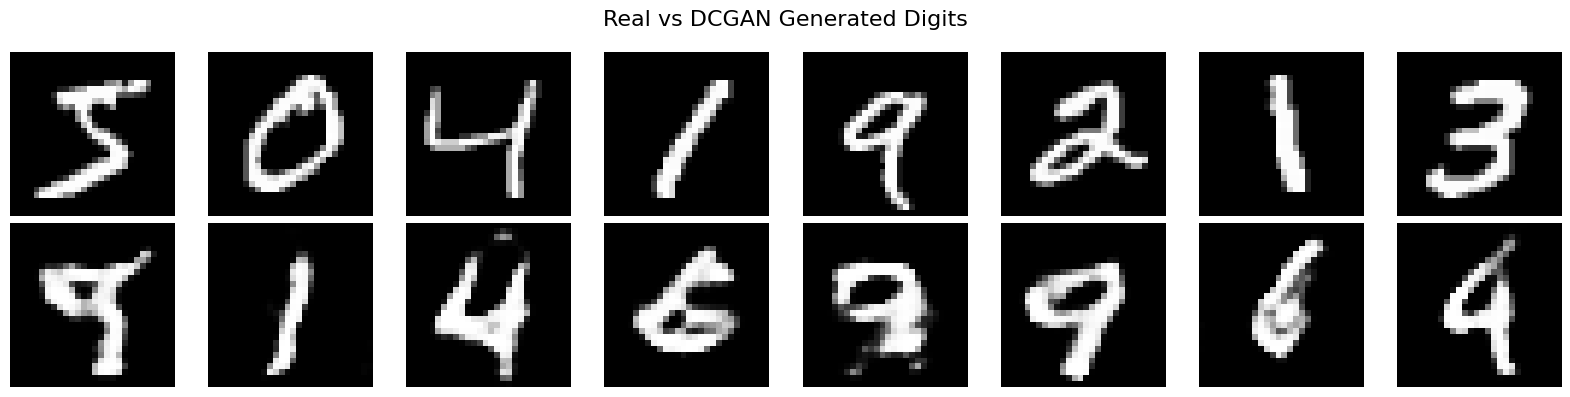

In [12]:
# CELL 12: Side-by-side comparison — Real vs Generated
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Top row: Real MNIST digits
for i in range(8):
    axes[0][i].imshow(X_train[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
    axes[0][i].axis('off')
axes[0][0].set_ylabel('Real', fontsize=14, rotation=0, labelpad=40)

# Bottom row: Generated digits
fake_noise = tf.random.normal([8, NOISE_DIM])
fake_images = generator(fake_noise, training=False)
for i in range(8):
    axes[1][i].imshow(fake_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
    axes[1][i].axis('off')
axes[1][0].set_ylabel('Fake', fontsize=14, rotation=0, labelpad=40)

plt.suptitle('Real vs DCGAN Generated Digits', fontsize=16)
plt.tight_layout()
plt.show()

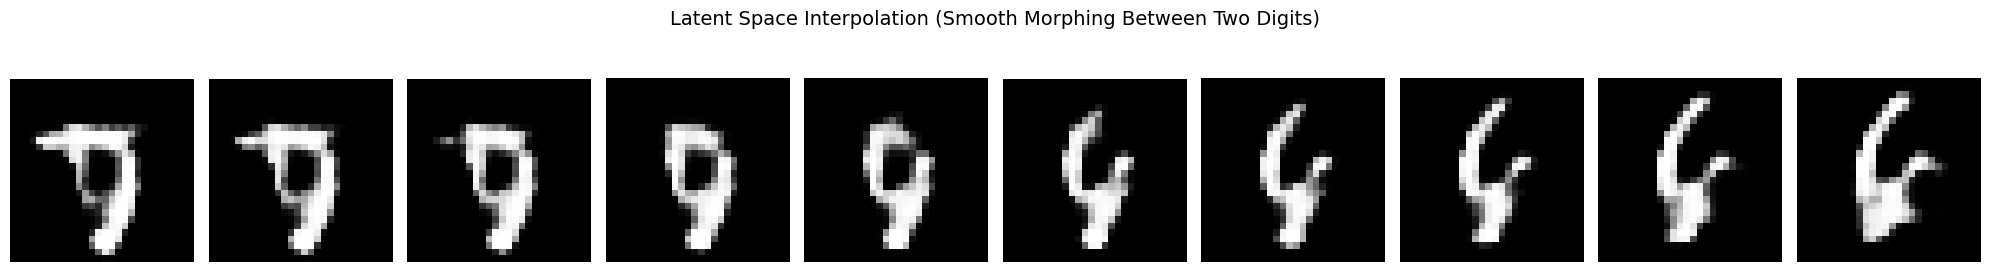

In [13]:
# CELL 13: Explore the latent space — interpolate between two digits
# This shows that the Generator learned a SMOOTH, meaningful representation

z1 = tf.random.normal([1, NOISE_DIM])  # Starting noise vector
z2 = tf.random.normal([1, NOISE_DIM])  # Ending noise vector

# Create 10 intermediate steps between z1 and z2
steps = 10
interpolated = []
for alpha in np.linspace(0, 1, steps):
    z = z1 * (1 - alpha) + z2 * alpha
    # Linear interpolation: gradually morph from z1 to z2
    interpolated.append(z)

interpolated = tf.concat(interpolated, axis=0)
# Stack all 10 vectors into one tensor: (10, 100)

generated_interp = generator(interpolated, training=False)

plt.figure(figsize=(20, 3))
for i in range(steps):
    plt.subplot(1, steps, i + 1)
    plt.imshow(generated_interp[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
    plt.axis('off')
plt.suptitle('Latent Space Interpolation (Smooth Morphing Between Two Digits)', fontsize=14)
plt.tight_layout()
plt.show()

# If the interpolation is SMOOTH (digits gradually morph), it means
# the Generator learned a meaningful structure, not just memorized images

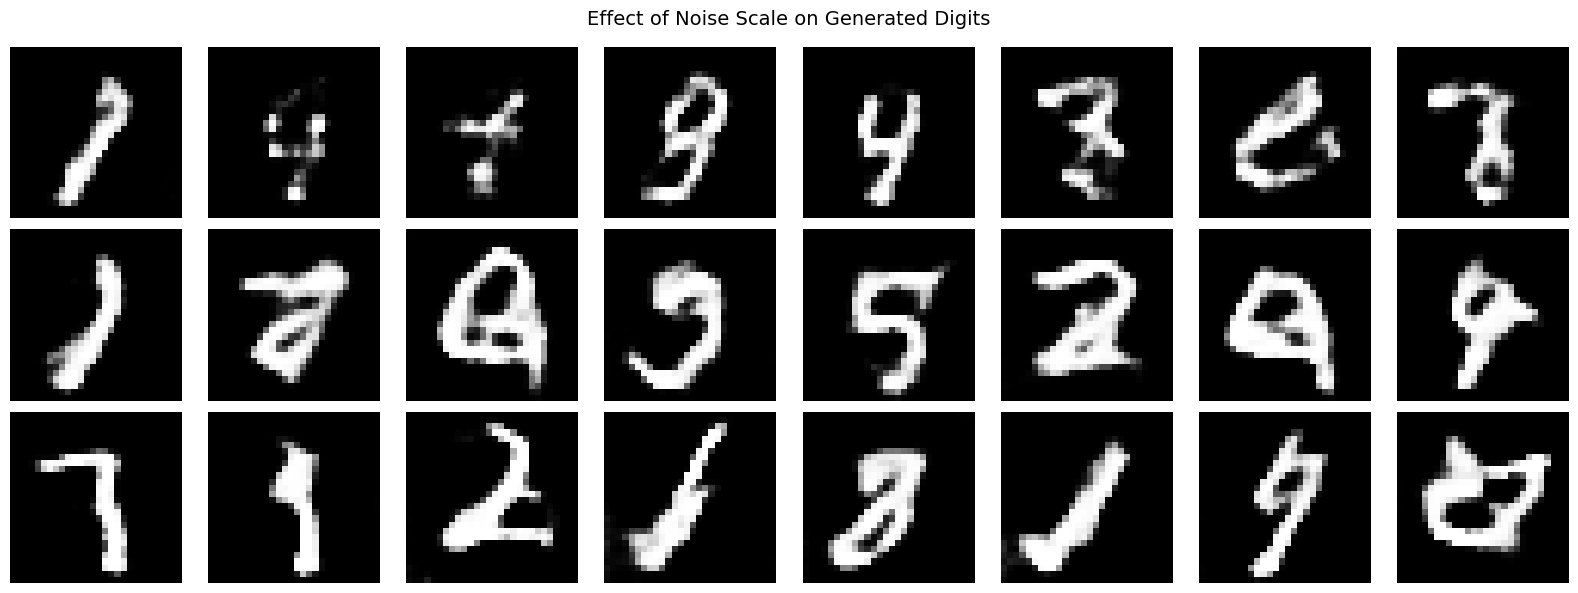

σ=0.5 → Conservative, more common-looking digits
σ=1.0 → Standard diversity
σ=1.5 → More extreme, unusual digit styles


In [14]:
# CELL 14: Generate images at different noise scales to show variety
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

noise_scales = [0.5, 1.0, 1.5]
# Different noise scales produce different diversity levels:
#   0.5 → more "average" looking digits (less variety)
#   1.0 → normal variety (standard)
#   1.5 → more unusual/extreme digits (more variety)

for row, scale in enumerate(noise_scales):
    noise = tf.random.normal([8, NOISE_DIM]) * scale
    imgs = generator(noise, training=False)
    for col in range(8):
        axes[row][col].imshow(imgs[col, :, :, 0] * 0.5 + 0.5, cmap='gray')
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f'σ={scale}', fontsize=12, rotation=0, labelpad=35)

plt.suptitle('Effect of Noise Scale on Generated Digits', fontsize=14)
plt.tight_layout()
plt.show()

print("σ=0.5 → Conservative, more common-looking digits")
print("σ=1.0 → Standard diversity")
print("σ=1.5 → More extreme, unusual digit styles")